### Logistic regression for imbalanced dataset

## generate and plot a synthetic imbalanced dataset


In [20]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [21]:
## generate and plot a synthetic imbalanced dataset
from collections import Counter
from sklearn.datasets import make_classification

In [22]:
## imbalanced dataset
X,y = make_classification(n_samples=1000,n_features=2,n_clusters_per_class=2,n_redundant=0,weights = [0.99],random_state=10)

In [23]:
X

array([[-0.54185501,  0.05720813],
       [-0.30746606,  0.24560955],
       [-1.03703596, -1.11868512],
       ...,
       [-0.66046886,  1.3324333 ],
       [-2.69901668,  2.73421239],
       [-1.83119322,  1.91963373]])

In [24]:
Counter(y)

Counter({np.int64(0): 984, np.int64(1): 16})

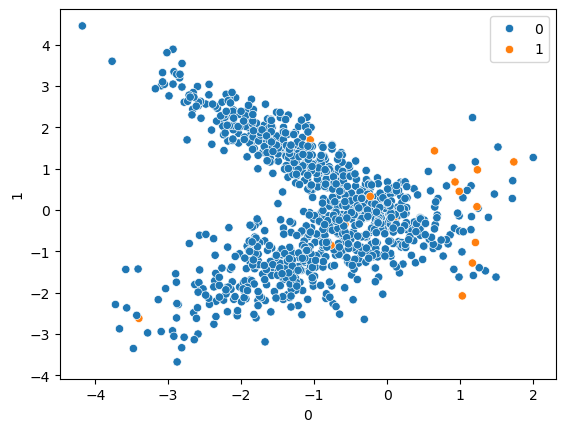

In [25]:
sns.scatterplot(x = pd.DataFrame(X)[0],y = pd.DataFrame(X)[1],hue = y)
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
### hyperparameter tuning
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
penalty=['l1', 'l2', 'elasticnet']
c_values=[100,10,1.0,0.1,0.01]
solver=['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [29]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [30]:
params = dict(penalty = penalty,C = c_values,solver = solver,class_weight = class_weight)

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold()
grid = GridSearchCV(estimator = model,param_grid=params,scoring = 'f1',cv = cv)

In [39]:
grid.fit(X_train,y_train)

c:\Users\mayan\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\mayan\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\mayan\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\mayan\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\mayan\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\mayan\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='f1')

In [40]:
grid.best_params_

{'C': 10, 'class_weight': {0: 1, 1: 50}, 'penalty': 'l2', 'solver': 'sag'}

In [41]:
grid.best_score_

np.float64(0.15047745947146346)

In [42]:
y_pred = grid.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
score = accuracy_score(y_test,y_pred)
print(score)
cm = confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred))
print(cm)

0.98
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       294
           1       0.00      0.00      0.00         6

    accuracy                           0.98       300
   macro avg       0.49      0.50      0.49       300
weighted avg       0.96      0.98      0.97       300

[[294   0]
 [  6   0]]


c:\Users\mayan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mayan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mayan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
y_pred

array([0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1])

# logistic regresion with ROC curve and ROC AUC score

In [45]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

In [46]:
# generate 2 class dataset
X,y = make_classification(n_samples=1000,n_classes=2,random_state=1)

In [48]:
## split the dataset into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [50]:
# created a dummy model with default 0 as output (mmajority class)
dummy_model_prob = [0 for _ in range((len(y_test)))]
dummy_model_prob

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [51]:
## basic logistic model
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [52]:
## prediction based on probability
model_prob = model.predict_proba(X_test)

In [53]:
##let's focus on one outcome
model_prob

array([[1.05252983e-03, 9.98947470e-01],
       [9.03979474e-01, 9.60205260e-02],
       [4.98946536e-01, 5.01053464e-01],
       [1.83435752e-01, 8.16564248e-01],
       [8.99408986e-01, 1.00591014e-01],
       [6.07719750e-01, 3.92280250e-01],
       [1.51824170e-01, 8.48175830e-01],
       [2.86232408e-01, 7.13767592e-01],
       [9.99979912e-02, 9.00002009e-01],
       [1.34810519e-01, 8.65189481e-01],
       [9.99568264e-01, 4.31736109e-04],
       [1.64476111e-01, 8.35523889e-01],
       [8.22873687e-01, 1.77126313e-01],
       [4.60903603e-01, 5.39096397e-01],
       [2.51021785e-01, 7.48978215e-01],
       [1.76733039e-01, 8.23266961e-01],
       [6.04167415e-02, 9.39583258e-01],
       [3.81636590e-01, 6.18363410e-01],
       [8.85148239e-01, 1.14851761e-01],
       [7.38360662e-01, 2.61639338e-01],
       [9.90412932e-01, 9.58706811e-03],
       [5.09267860e-01, 4.90732140e-01],
       [1.06145034e-01, 8.93854966e-01],
       [1.99494399e-03, 9.98005056e-01],
       [8.661823

In [54]:
## let's focus on positive outcome
model_prob = model_prob[:,1]

In [55]:
## let's calculate the scores
dummy_model_auc = roc_auc_score(y_test,dummy_model_prob)
model_auc = roc_auc_score(y_test,model_prob)
print(dummy_model_auc)
print(model_auc)

0.5
0.8995383380168608


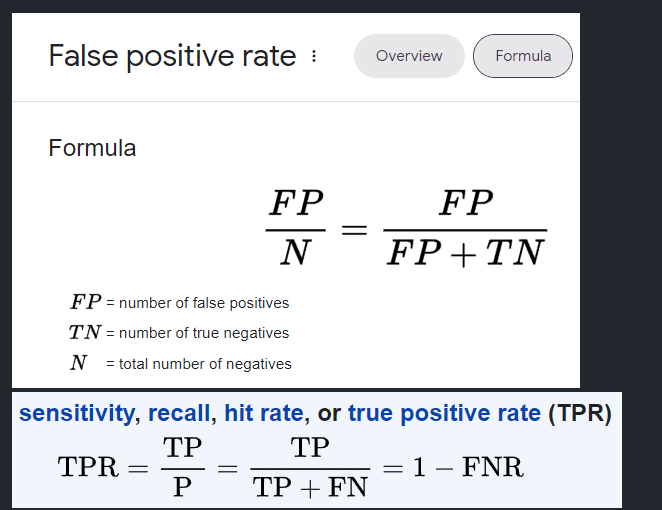

In [60]:
## calculate ROC curves
dummy_fpr,dummy_tpr, _ = roc_curve(y_test,dummy_model_prob)
model_fpr,model_tpr, thresholds = roc_curve(y_test,model_prob)

In [61]:
dummy_fpr,dummy_tpr,model_fpr,model_tpr

(array([0., 1.]),
 array([0., 1.]),
 array([0.        , 0.        , 0.        , 0.00943396, 0.00943396,
        0.01886792, 0.01886792, 0.02830189, 0.02830189, 0.03773585,
        0.03773585, 0.04716981, 0.04716981, 0.05660377, 0.05660377,
        0.06603774, 0.06603774, 0.0754717 , 0.0754717 , 0.08490566,
        0.08490566, 0.09433962, 0.09433962, 0.10377358, 0.10377358,
        0.12264151, 0.12264151, 0.13207547, 0.13207547, 0.14150943,
        0.14150943, 0.16981132, 0.16981132, 0.17924528, 0.17924528,
        0.18867925, 0.18867925, 0.19811321, 0.19811321, 0.21698113,
        0.21698113, 0.22641509, 0.22641509, 0.23584906, 0.23584906,
        0.24528302, 0.24528302, 0.25471698, 0.25471698, 0.32075472,
        0.32075472, 0.33018868, 0.33018868, 0.39622642, 0.39622642,
        0.4245283 , 0.4245283 , 0.54716981, 0.54716981, 0.55660377,
        0.55660377, 0.60377358, 0.60377358, 1.        ]),
 array([0.        , 0.0106383 , 0.22340426, 0.22340426, 0.27659574,
        0.27659574, 0.

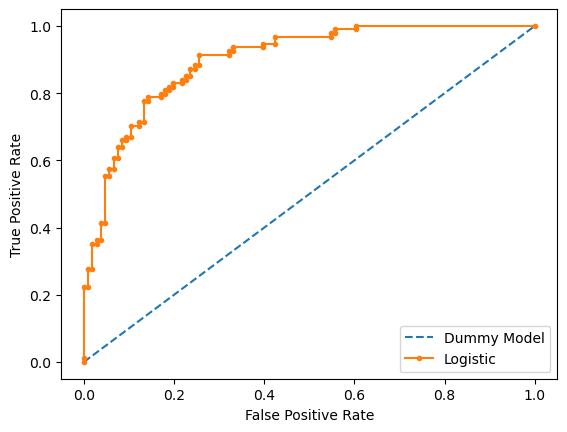

In [62]:
## plot roc curves
pyplot.plot(dummy_fpr, dummy_tpr, linestyle = '--',label = 'Dummy Model')
pyplot.plot(model_fpr, model_tpr, marker = '.',label = 'Logistic')

## axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')

# show the legend
pyplot.legend()

#show the plot()
pyplot.show()

In [63]:
thresholds

array([           inf, 9.99746470e-01, 9.57758694e-01, 9.56874850e-01,
       9.44692000e-01, 9.40798698e-01, 9.27422045e-01, 9.25366478e-01,
       9.24251909e-01, 9.23295200e-01, 8.99543928e-01, 8.97529800e-01,
       8.48175830e-01, 8.43011275e-01, 8.23266961e-01, 8.22695247e-01,
       8.16564248e-01, 8.09487362e-01, 8.04548646e-01, 7.94948723e-01,
       7.81078622e-01, 7.60448777e-01, 7.60342634e-01, 7.51848883e-01,
       7.40369385e-01, 7.33284233e-01, 7.29232595e-01, 7.27168990e-01,
       6.55452536e-01, 6.52640043e-01, 6.46430871e-01, 6.30467947e-01,
       6.20343499e-01, 6.18363410e-01, 6.01171149e-01, 5.99570512e-01,
       5.57425863e-01, 5.47504289e-01, 5.39096397e-01, 5.01053464e-01,
       4.97145320e-01, 4.94836261e-01, 4.90732140e-01, 4.84229485e-01,
       4.72109796e-01, 4.60005139e-01, 4.58293698e-01, 4.49274042e-01,
       4.08140395e-01, 3.18539320e-01, 3.05995455e-01, 2.96107469e-01,
       2.84186360e-01, 2.12193211e-01, 2.02795674e-01, 1.77126313e-01,
      

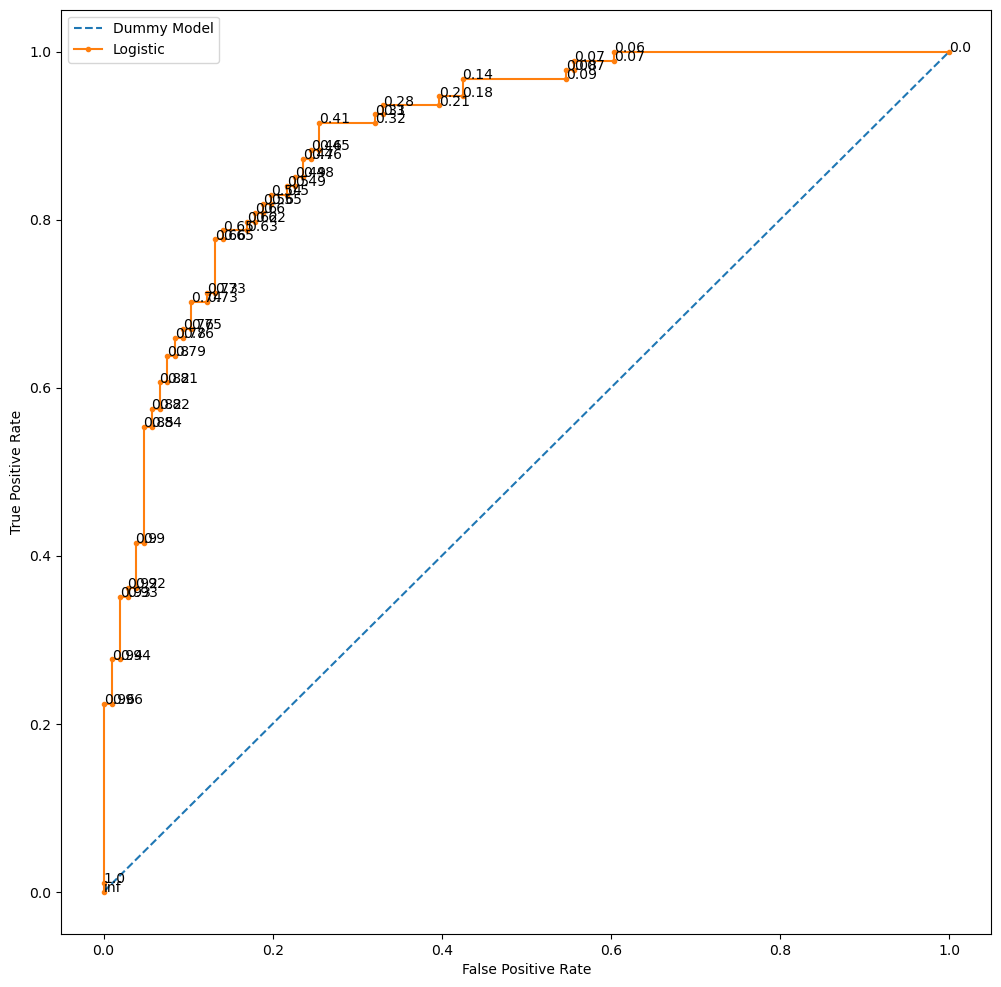

In [67]:
# plot the roc curve for the model
import numpy as np
from matplotlib import pyplot

# 1. Create the figure (Adjusted to a square ratio for a standard ROC curve)
fig = pyplot.figure(figsize=(12, 12)) 

# 2. Add the subplot FIRST
ax = fig.add_subplot(111) 

# 3. Plot the lines directly onto the 'ax' object
ax.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
ax.plot(model_fpr, model_tpr, marker='.', label='Logistic')

# 4. Add annotations
for xyz in zip(model_fpr, model_tpr, thresholds):
    ax.annotate('%s' % np.round(xyz[2],2), xy=(xyz[0],xyz[1]))

# 5. Axis labels and legend
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

# 6. Show the plot
pyplot.show()